In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
from PIL import Image
import random

In [2]:
# ---------------------------
# 1. Define Rotation Dataset
# ---------------------------
class RotationDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.rotations = [0, 90, 180, 270]

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]
        # Choose a random rotation
        rotation_label = random.choice(self.rotations)
        rotated_img = img.rotate(rotation_label)
        label = self.rotations.index(rotation_label)
        return transforms.ToTensor()(img), transforms.ToTensor()(rotated_img), label


In [3]:
# ---------------------------
# 2. Define a Simple CNN
# ---------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),  # 32x32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                           # 32x16x16
            nn.Conv2d(32, 64, 3, stride=1, padding=1), # 64x16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                           # 64x8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [4]:
# ---------------------------
# 3. Prepare Data
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    # transforms.ToTensor(),
])

base_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
rotation_dataset = RotationDataset(base_dataset)
train_loader = DataLoader(rotation_dataset, batch_size=64, shuffle=True)

In [5]:
# ---------------------------
# 4. Train the CNN (CPU)
# ---------------------------
import time

device = torch.device('cpu')
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
for epoch in range(epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0

    for _, imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        end_time = time.time()
        epoch_time = end_time - start_time

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Time: {epoch_time:.2f}s")

print("Training finished (CPU only).")
torch.save(model.state_dict(), "rotation_cnn.pth")

Epoch [1/10], Loss: 1.0524, Time: 9.78s
Epoch [2/10], Loss: 0.9097, Time: 9.68s
Epoch [3/10], Loss: 0.8461, Time: 9.71s
Epoch [4/10], Loss: 0.8008, Time: 9.73s
Epoch [5/10], Loss: 0.7669, Time: 9.56s
Epoch [6/10], Loss: 0.7383, Time: 9.52s
Epoch [7/10], Loss: 0.7154, Time: 9.68s
Epoch [8/10], Loss: 0.6976, Time: 9.81s
Epoch [9/10], Loss: 0.6776, Time: 10.35s
Epoch [10/10], Loss: 0.6611, Time: 10.51s
Training finished (CPU only).


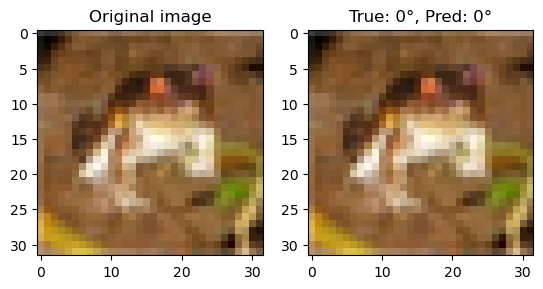

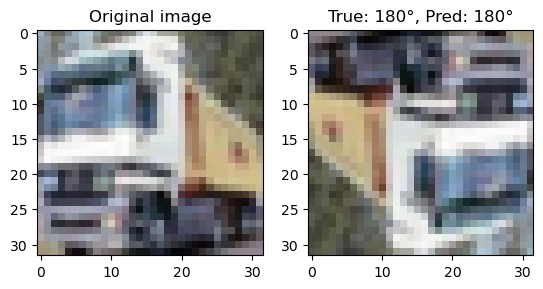

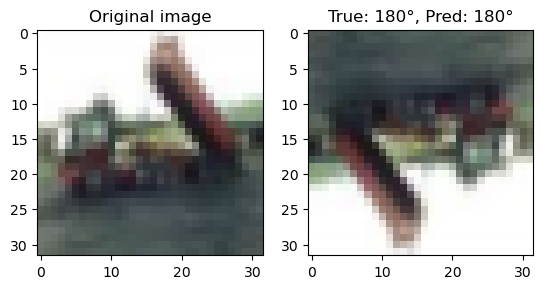

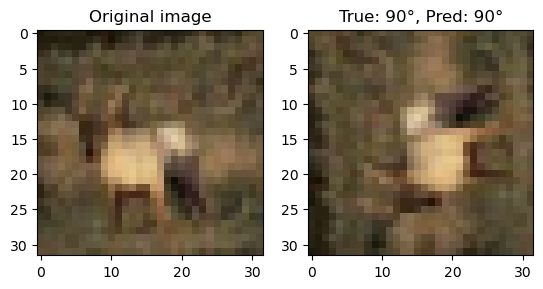

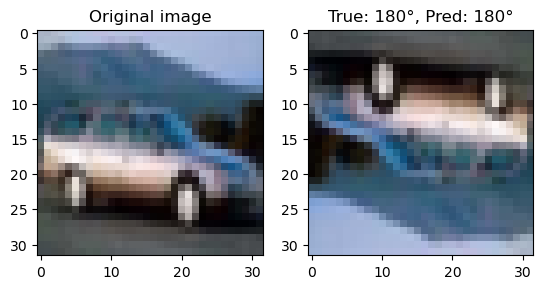

In [7]:
# ---------------------------
# 5. Visualize Some Predictions
# ---------------------------
import matplotlib.pyplot as plt
# plt.figure(figsize=(1,1))

angles = [0, 90, 180, 270]
model.eval()
for i in range(5):
    original, rotated, label = rotation_dataset[i]
    with torch.no_grad():
        pred = model(rotated.unsqueeze(0))
        predicted = pred.argmax(dim=1).item()
    plt.subplot(1,2,1), plt.imshow(original.permute(1,2,0))
    plt.title("Original image")
    plt.subplot(1,2,2), plt.imshow(rotated.permute(1,2,0))
    plt.title(f"True: {angles[label]}°, Pred: {angles[predicted]}°")
    plt.show()